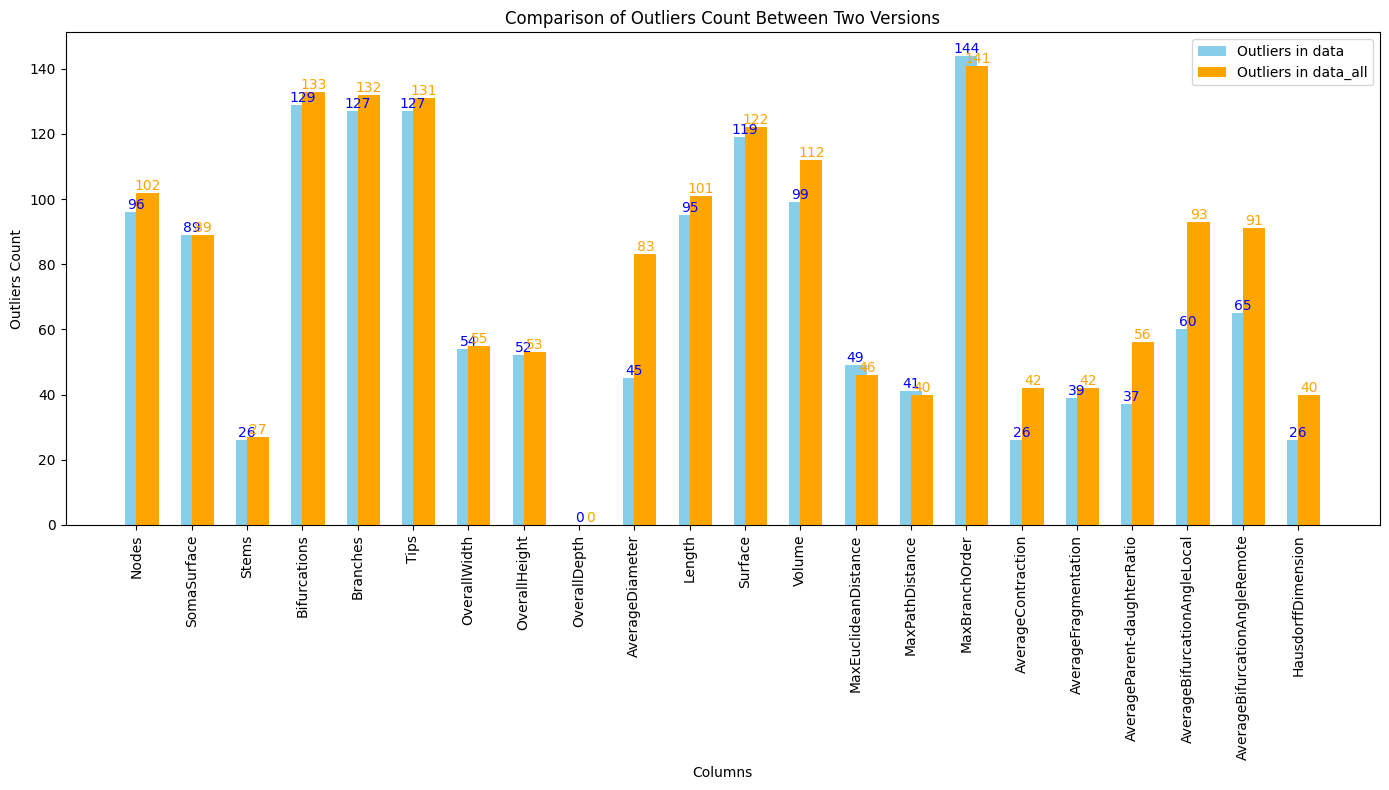

In [6]:
#对比level1剔除前后异常值
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# 计算异常值数量和占比
def count_outliers_with_ratio(df):
    outlier_info = pd.DataFrame(columns=["Outliers_Count", "Outliers_Ratio"])
    for column in df.columns:
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        
        outlier_info.loc[column] = [outliers.shape[0], outliers.shape[0] / df.shape[0]]
    
    return outlier_info


# 读取CSV文件
data = pd.read_csv(r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\cell_type_sorted\soma_merge\2radius\interneuron\interneuron_fea_1888.csv")
data_all = pd.read_csv(r"Z:\SEU-ALLEN\Users\XiaoqinGu\dataset\H01\v2\cell_type_sorted\soma_merge\2radius\interneuron\interneuron_fea.csv")
# 选择数值列
data_numeric = data.select_dtypes(include=[float, int])
dataall_numeric = data_all.select_dtypes(include=[float, int])
# 获取异常值信息
outlier_info_df = count_outliers_with_ratio(data_numeric)
outlierall_info_df = count_outliers_with_ratio(dataall_numeric)

# 合并两个数据框，用于比较
outlier_comparison_df = pd.merge(outlier_info_df, outlierall_info_df, left_index=True, right_index=True, suffixes=('_data', '_data_all'))

# 绘制柱状图比较异常值数量
plt.figure(figsize=(14, 8))

# 设置柱形图的位置
x = range(len(outlier_comparison_df))

# 绘制data中的异常值数量
bars_data = plt.bar(x, outlier_comparison_df['Outliers_Count_data'], width=0.4, label='Outliers in data', color='skyblue', align='center')

# 绘制data_all中的异常值数量
bars_data_all = plt.bar(x, outlier_comparison_df['Outliers_Count_data_all'], width=0.4, label='Outliers in data_all', color='orange', align='edge')

# 在柱形图上方添加具体数值
for bar in bars_data:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height)}', ha='center', va='bottom', color='blue', fontsize=10)

for bar in bars_data_all:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height)}', ha='center', va='bottom', color='orange', fontsize=10)

# 设置图表标题和标签
plt.title('Comparison of Outliers Count Between Two Versions')
plt.xlabel('Columns')
plt.ylabel('Outliers Count')
plt.xticks(x, outlier_comparison_df.index, rotation=90)
plt.legend()

# 显示图表
plt.tight_layout()
plt.show()
